# **SleepDisorderRiskPrediction - Avance 1/2**
Gabriela Chimali Nava Ramírez

19/04/2026



In [2]:
import pandas as pd
import os
from google.colab import drive
from sklearn.model_selection import train_test_split
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga del dataframe

In [3]:
df_path = '/content/drive/MyDrive/8vo/IA/sleep_health_dataset.csv'
#df_path = '../sleep_health_dataset.csv'
df = pd.read_csv(df_path)
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [4]:
print('>> Conteo por clase:')
print(df['sleep_disorder_risk'].value_counts())
print('\n>> Balance de clases (%):')
print((df['sleep_disorder_risk'].value_counts(normalize=True)*100))

>> Conteo por clase:
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

>> Balance de clases (%):
sleep_disorder_risk
Healthy     54.156
Mild        33.479
Moderate     8.299
Severe       4.066
Name: proportion, dtype: float64


## 2. Preprocesamiento

### 2.1. Limpieza inicial
* Transformar las 4 clases de la variable objetivo a valores numéricos enteros
* Eliminar "person_id"
* Convertir en boleano "day_type"

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean = df.copy()
df_clean['sleep_disorder_risk'] = le.fit_transform(
    df_clean['sleep_disorder_risk'])
df_clean['sleep_disorder_risk'].unique()

array([0, 3, 1, 2])

In [6]:
df_clean = df_clean.drop(['person_id','cognitive_performance_score','felt_rested'], axis=1)
df_clean['day_type'] = df_clean['day_type'].map({'Weekday': 1, 'Weekend': 0})
df_clean.shape

(100000, 29)

### 2.2. One-hot encoding para variables categóricas

In [7]:
cat_cols = ['gender','occupation','country','chronotype',
            'mental_health_condition','season']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
df_encoded.head(2)

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,country_UK,country_USA,chronotype_Morning,chronotype_Neutral,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy,season_Spring,season_Summer,season_Winter
0,29,25.7,6.19,6.6,22.5,19.3,16,3,0,0.0,...,False,False,True,False,False,False,True,False,False,False
1,55,22.0,8.32,6.9,26.9,14.9,17,4,0,0.0,...,False,True,False,True,False,False,True,False,False,True


#### **Matriz correlación**

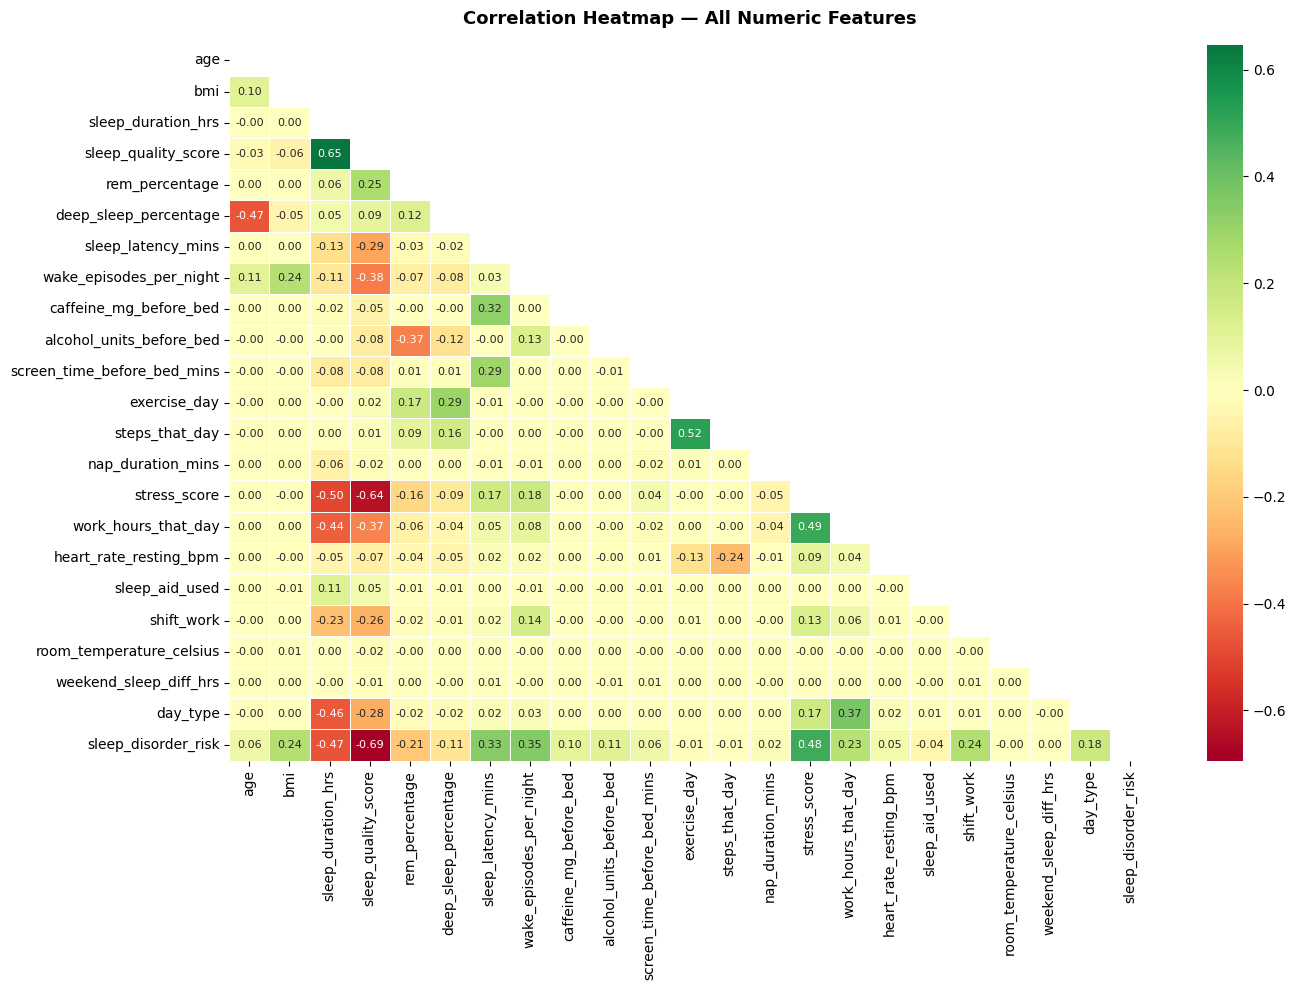

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
numeric_df = df_encoded.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.4,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — All Numeric Features',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_06_correlation.png', bbox_inches='tight')
plt.show()

### 2.3. División de conjuntos

In [9]:
y = df_encoded['sleep_disorder_risk']
X = df_encoded.drop('sleep_disorder_risk', axis=1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} muestras")
print(f"Validation: {len(X_val)} muestras")
print(f"Test: {len(X_test)} muestras")

Train: 70000 muestras
Validation: 15000 muestras
Test: 15000 muestras


### 2.4. Estandarización de variables numéricas
Usando sólo métricas de train para evitar *data leakage*.

In [10]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age','bmi','sleep_duration_hrs','sleep_quality_score',
            'rem_percentage','deep_sleep_percentage','sleep_latency_mins',
            'wake_episodes_per_night','alcohol_units_before_bed',
            'screen_time_before_bed_mins','steps_that_day','nap_duration_mins',
            'stress_score','work_hours_that_day','heart_rate_resting_bpm',
            'room_temperature_celsius','weekend_sleep_diff_hrs',
            'caffeine_mg_before_bed']

scaler = StandardScaler()

# Escalar sólo con las métricas del conjunto train
scaler.fit(X_train[num_cols])

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Aplicar estandarización
X_train_scaled[num_cols] = scaler.transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled[num_cols].head(2)

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,alcohol_units_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,caffeine_mg_before_bed
43729,-0.517227,0.898731,0.627451,0.950891,-0.039279,-0.294163,0.812106,0.858752,-0.565530,0.412854,-0.299135,-0.696964,-0.638921,0.045979,1.587187,1.124804,-0.942641,0.593244
38668,0.839355,-0.172701,0.164240,0.486082,0.488519,-0.247082,0.285746,1.899448,0.376347,-1.022756,0.171498,-0.696964,-0.886267,0.390075,-0.353408,-0.499811,0.226815,-0.556955


In [13]:
X_train_scaled.shape

(70000, 57)

## 3. Guardar conjutos preprocesados

In [ ]:
dir_path = os.path.dirname(df_path)

train_df = pd.concat([X_train_scaled, y_train], axis=1)
val_df = pd.concat([X_val_scaled, y_val], axis=1)
test_df = pd.concat([X_test_scaled, y_test], axis=1)

train_df.to_csv(os.path.join(dir_path, 'train_set.csv'), index=False)
val_df.to_csv(os.path.join(dir_path, 'val_set.csv'), index=False)
test_df.to_csv(os.path.join(dir_path, 'test_set.csv'), index=False)

print(f"Conjuntos guardados en: {dir_path}")

Conjuntos en: /content/drive/MyDrive/8vo/IA
